<a href="https://colab.research.google.com/github/ArtNizh/SOTA/blob/main/Lab1/SOTA_%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №1: Transfer learning и fine-tuning визуального backbone

**Версия:** студенческая  
**Курс:** «Современное компьютерное зрение»

> Сначала выполните notebook в режиме `FAST_DEV_RUN=True`, затем запускайте полный эксперимент. Сохраняйте метрики и checkpoints в `artifacts/`.


## Цели обучения

После работы студент должен уметь:

- Подготовить CIFAR-10 или собственный малый датасет без утечки связанных объектов.
- Сравнить frozen, partial и full fine-tuning ResNet18.
- Построить confusion matrix и проверить corruption shift.


## Теоретическая часть

Предобученный backbone реализует отображение $f_\theta(x)=z$. Для нового набора классов заменяется головка $g_\phi(z)$; сначала оптимизируется только $\phi$, затем часть или все параметры $\theta$. Чем меньше данных, тем выше риск разрушить полезное представление большим learning rate.

Глубокие сети страдают от переобучения на малых данных: чтобы выучить с нуля хорошие фильтры, нужно много примеров. При transfer learning мы стартуем не с случайных весов, а с уже информативных — и дообучаем их под новую задачу. Это ускоряет сходимость и повышает качество, особенно когда данных мало.

![Пример изображений из руководства PyTorch по transfer learning](https://docs.pytorch.org/tutorials/_images/sphx_glr_transfer_learning_tutorial_001.png)

Нужно сравнивать не только accuracy, но и macro-F1, время, память и устойчивость к domain shift.


### Математическая постановка

Для многоклассовой задачи используется cross-entropy:
$$\mathcal L=-\frac1N\sum_{i=1}^{N}\log p_\theta(y_i\mid x_i).$$
Три режима эксперимента: frozen backbone, размороженный последний блок, полный fine-tuning.

Обозначим $\Theta$ — множество всех параметров. Мы управляем тем, какие параметры получают градиент

**(а) Frozen backbone.** Обучаем только головку:

$$
\phi^{(t+1)} = \phi^{(t)} - \eta \nabla_\phi \mathcal{L}, \quad \theta = \text{const}.
$$

Плюсы: быстро, минимум памяти (backbone можно даже кэшировать в виде признаков), устойчиво к переобучению. Минусы: представление $\theta$ фиксировано; если целевая задача сильно отличается от ImageNet, точность ограничена.

**(б) Partial fine-tuning.** Размораживаем последний блок (например, `layer4` ResNet18) и головку:

$$
\{\theta_{\text{last}}, \phi\}^{(t+1)} = \{\theta_{\text{last}}, \phi\}^{(t)} - \eta \nabla_{\{\theta_{\text{last}}, \phi\}} \mathcal{L}, \quad \theta_{\text{early}} = \text{const}.
$$

Это компромисс: ранние слои (универсальные признаки) не трогаются, поздние (задаче-специфичные) адаптируются.

**(в) Full fine-tuning.** Обучаем всё:

$$
\Theta^{(t+1)} = \Theta^{(t)} - \eta \nabla_\Theta \mathcal{L}.
$$

Потенциально максимальное качество, но:
- на малых данных легко **разрушить** предобученное представление большим $\eta$ (catastrophic forgetting);
- требуются меньший learning rate и больше эпох;
- дорого по времени и памяти.

### Материалы

- [PyTorch Transfer Learning Tutorial](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)
- [torchvision models](https://pytorch.org/vision/stable/models.html)

Ссылки даны как дополнительный материал. При изменении API сверяйтесь с актуальной официальной документацией и фиксируйте версии зависимостей.


## Практическое задание

1. Подготовить CIFAR-10 или собственный малый датасет без утечки связанных объектов.
2. Сравнить frozen, partial и full fine-tuning ResNet18.
3. Построить confusion matrix и проверить corruption shift.

**Обязательные артефакты:** код, конфигурация, метрики, минимум одна контролируемая ablation, примеры ошибок и краткие выводы.


### Профиль вычислений

- **Основной режим:** ResNet18, FP32/FP16, 32–224 px.
- **Ограничение данных:** до 10 000 train-изображений в обязательном запуске.
- **Fallback:** CPU/FAST_DEV_RUN на подвыборке.
- Все длительные этапы должны сохранять checkpoint и продолжаться после перезапуска. Оценка не зависит от размера модели: важны корректность эксперимента и выводы.


**Оценивание.** Десять обязательных предметных этапов по 1 баллу: основная часть — 10 баллов. Творческий бонус — отдельно 1 балл, не заменяет обязательные этапы. Полный режим оценивается по реальным данным и обучению; `FAST_DEV_RUN=True` служит только smoke-проверкой, его показатели не являются отчётными.


## Реализация


In [ ]:
# Базовое воспроизводимое окружение
from pathlib import Path
import json, os, random, time
import numpy as np

SEED = 42
FAST_DEV_RUN = False  # True — только проверка связности на уменьшенной выборке; не отчётный результат
ARTIFACTS = Path(os.getenv("CV_ARTIFACTS", "artifacts"))
ARTIFACTS.mkdir(exist_ok=True)
random.seed(SEED); np.random.seed(SEED)
try:
    import torch
    torch.manual_seed(SEED)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    torch = None
    DEVICE = "cpu"
# Датасеты курса лежат в общем каталоге <корень курса>/data:
# notebook выполняется из labs/lab_XX_*/, поэтому корень курса — cwd.parent.parent.
# Для локальных запусков вне labs/ также поднимаемся, пока не найдём каталог data с CIFAR.
_CANDIDATES = [Path.cwd().parent.parent / "data", Path.cwd().parent / "data", Path.cwd() / "data"]
DATA_ROOT = Path(os.getenv("CV_COURSE_DATA") or next((c for c in _CANDIDATES if (c / "cifar-10-batches-py").exists()), _CANDIDATES[0]))
DATA_ROOT.mkdir(parents=True, exist_ok=True)
print({"device": DEVICE, "fast_dev_run": FAST_DEV_RUN, "data_root": str(DATA_ROOT)})


{'device': 'cpu', 'fast_dev_run': False, 'data_root': '/data'}


In [ ]:
def check(condition, message):
    """Мини-проверка в стиле YAAM: молчит, если всё хорошо; печатает, если найдена проблема."""
    if condition:
        print(f"✔ {message}")
    else:
        print(f"✘ ВНИМАНИЕ: {message}")

### Разделение CIFAR-10

*Вес: 1 балл.*

**Постановка.** Изоляция test необходима для оценки обобщения без подбора по тестовым меткам.

Выполните следующие действия:
1. Загрузите CIFAR-10 и разделите train на стратифицированные train и validation.
2. Подготовьте DataLoader с детерминированным test-преобразованием.

**Результат.** Непересекающиеся train, validation и test и загрузчики train_loader, val_loader, test_loader.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Загружаем CIFAR-10, делаем стратифицированное разбиение train → train/val (чтобы сохранить пропорции классов), отдельно оставляем test. Готовим три DataLoader'а: train с аугментациями (только для train!), val/test с детерминированным препроцессингом

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix
from collections import Counter

# --- Гиперпараметры эксперимента ---
IMG_SIZE    = 96        # разумный компромисс между 32 (оригинал) и 224 (ImageNet)
BATCH_SIZE  = 128
NUM_WORKERS = 2
NUM_EPOCHS  = 5         # одинаковый бюджет для всех режимов
LR_HEAD     = 1e-3      # голова учится с нуля — крупный шаг
LR_BODY     = 1e-4      # backbone предобучен — маленький шаг, чтобы не «сломать»
NUM_CLASSES = 10
# Среднее/σ CIFAR-10 — стандартные значения, используются предобученными BN-слоями
CIFAR_MEAN  = (0.4914, 0.4822, 0.4465)
CIFAR_STD   = (0.2470, 0.2435, 0.2616)

# Аугментации только для train: случайный кроп + флип повышают робастность
train_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomCrop(IMG_SIZE, padding=8),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])
# Val/test — детерминированный препроцессинг: только resize + нормализация
eval_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# --- Загрузка датасета ---
train_full = datasets.CIFAR10(DATA_ROOT, train=True,  download=True, transform=train_tf)
test_set   = datasets.CIFAR10(DATA_ROOT, train=False, download=True, transform=eval_tf)

# Стратифицированное разбиение: 15% train уходит в val, пропорции классов сохраняются
targets = np.array(train_full.targets)
idx_train, idx_val = train_test_split(
    np.arange(len(targets)), test_size=0.15, stratify=targets, random_state=SEED
)
train_set = Subset(train_full, idx_train)
val_set   = Subset(train_full, idx_val)

# Ограничение бюджета данных: 10k train в полном режиме, 1k в FAST_DEV_RUN
MAX_TRAIN = 10_000
if FAST_DEV_RUN:
    MAX_TRAIN = 1_000
if len(train_set) > MAX_TRAIN:
    rng = np.random.RandomState(SEED)  # фиксированный seed -> воспроизводимая подвыборка
    sel = rng.choice(len(train_set), MAX_TRAIN, replace=False)
    train_set = Subset(train_set, sel)

# --- DataLoader'ы ---
# train: shuffle=True, drop_last=True (стабильный размер батча для BatchNorm в train-режиме)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
# val/test: shuffle=False — порядок фиксирован, удобно сопоставлять индексы
val_loader   = DataLoader(val_set,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# --- Проверки корректности разбиения ---
def _labels(ds):
    """Достаёт метки из Subset (в т.ч. вложенных) или обычного Dataset."""
    if isinstance(ds, Subset):
        base_labels = _labels(ds.dataset)      # рекурсивный разворот вложенных Subset
        return base_labels[ds.indices]
    return np.array(ds.targets)

y_tr, y_va = _labels(train_set), _labels(val_set)
y_te = np.array(test_set.targets)              # test_set — обычный CIFAR10, .targets есть

check(len(train_set) > 0 and len(val_set) > 0 and len(test_set) > 0,
      "train/val/test непусты")
check(set(idx_train.tolist()).isdisjoint(set(idx_val.tolist())),
      "индексы train и val не пересекаются (нет утечки)")
check(len(train_set) <= MAX_TRAIN, f"train ≤ {MAX_TRAIN}")
print("Размеры:", {"train": len(train_set), "val": len(val_set), "test": len(test_set)})
print("Классов train:", len(Counter(y_tr)), "val:", len(Counter(y_va)))

✔ train/val/test непусты
✔ индексы train и val не пересекаются (нет утечки)
✔ train ≤ 10000
Размеры: {'train': 10000, 'val': 7500, 'test': 10000}
Классов train: 10 val: 10


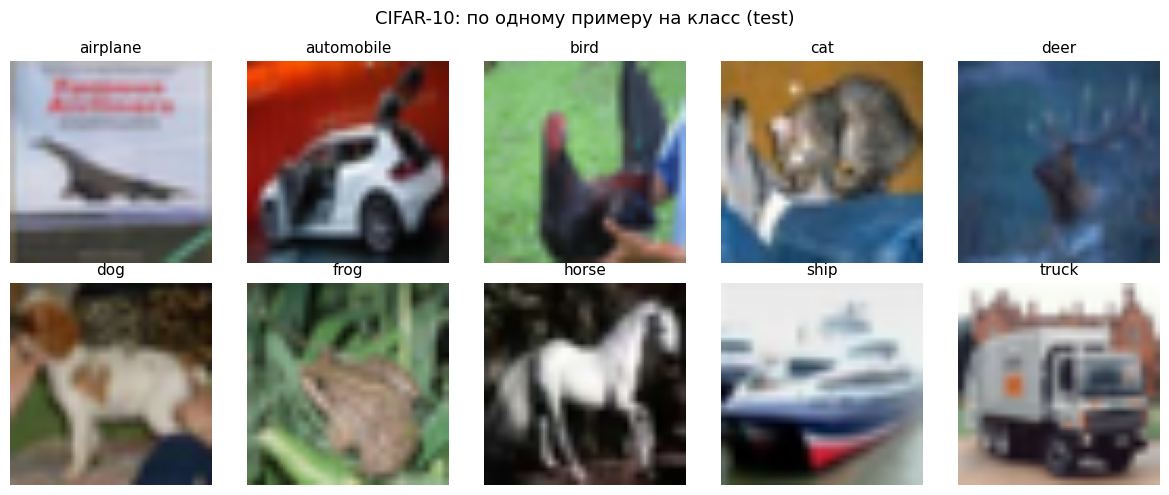

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# --- Собираем по одному индексу на класс из test_set ---
class_names = test_set.classes
targets_all = np.array(test_set.targets)

# для каждого класса берём первый попавшийся индекс
one_per_class = {}
for cls in range(len(class_names)):
    idx = np.where(targets_all == cls)[0][0]
    one_per_class[cls] = idx

# --- Сетка 2x5 ---
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for cls, ax in zip(range(len(class_names)), axes):
    idx = one_per_class[cls]
    # test_set.transform = eval_tf -> изображение уже нормализовано
    x, y = test_set[idx]
    # денормализация обратно в [0,1] для показа
    mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    std  = torch.tensor(CIFAR_STD ).view(3, 1, 1)
    img = (x * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(class_names[y], fontsize=11)
    ax.axis("off")

fig.suptitle("CIFAR-10: по одному примеру на класс (test)", fontsize=13)
plt.tight_layout()
plt.show()

### Backbone и функции обучения

*Вес: 1 балл.*

**Постановка.** Режимы заморозки изменяют множество обновляемых параметров. Сравнивать их можно лишь при одинаковой функции потерь.

Выполните следующие действия:
1. Создайте ResNet18 с новой десятиклассовой головой.
2. Определите функции обучения и вычисления accuracy, macro-F1, матрицы ошибок.

**Результат.** Функции build_model, train_epoch и evaluate.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [ ]:
# ---------- Модель ----------
def build_model(mode: str, arch: str = "resnet18", num_classes: int = NUM_CLASSES):
    """
    mode ∈ {"frozen", "partial", "full"}:
      frozen  — обучается только новая голова;
      partial — голова + последний блок backbone (layer4 / features.7);
      full    — все параметры.
    """
    assert mode in {"frozen", "partial", "full"}
    if arch == "resnet18":
        model = models.resnet18(weights="IMAGENET1K_V1")  # предобученные веса ImageNet
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)    # новая голова под C=10
        head_prefix, block_prefix = "fc", "layer4"
    elif arch == "efficientnet_b0":
        model = models.efficientnet_b0(weights="IMAGENET1K_V1")
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
        head_prefix, block_prefix = "classifier", "features.7"
    else:
        raise ValueError(arch)

    # Сначала замораживаем всё — будем размораживать точечно
    for p in model.parameters():
        p.requires_grad = False

    # Голова обучается всегда, независимо от режима
    for name, p in model.named_parameters():
        if name.startswith(head_prefix):
            p.requires_grad = True

    # Partial/full: размораживаем последний блок backbone
    if mode in {"partial", "full"}:
        for name, p in model.named_parameters():
            if name.startswith(block_prefix):
                p.requires_grad = True

    # Full: размораживаем вообще всё
    if mode == "full":
        for p in model.parameters():
            p.requires_grad = True

    return model.to(DEVICE)


def count_trainable(model):
    """Возвращает число всех/обучаемых параметров и их долю — для отчёта по стоимости."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total": int(total), "trainable": int(trainable),
            "ratio": float(trainable / max(1, total))}


# ---------- Одна эпоха ----------
def train_epoch(model, loader, optimizer, criterion, scaler=None):
    """Обучение одной эпохи. scaler != None -> AMP (mixed precision) на CUDA."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        # non_blocking=True — асинхронный перенос H2D параллельно с вычислениями
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)  # set_to_none=True экономит память
        if scaler is not None:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()   # масштабируем loss, чтобы градиенты не underflow
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
        # взвешиваем loss по размеру батча — корректное среднее по эпохе
        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return running_loss / total, correct / total


# ---------- Оценка ----------
@torch.no_grad()  # отключаем autograd — экономим память и время
def evaluate(model, loader, return_preds=False):
    """Loss, accuracy, macro-F1, confusion matrix. При return_preds=True добавляет сырые предсказания."""
    model.eval()
    criterion = nn.CrossEntropyLoss()
    loss_sum, correct, total = 0.0, 0, 0
    all_preds, all_targets = [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)
        loss_sum += loss.item() * x.size(0)
        preds = logits.argmax(1)
        correct += (preds == y).sum().item()
        total += x.size(0)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y.cpu().numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_targets)
    metrics = {
        "loss": loss_sum / total,
        "accuracy": correct / total,
        # macro-F1 усредняет F1 по классам без учёта частот — устойчив к дисбалансу
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }
    if return_preds:
        metrics["preds"] = y_pred
        metrics["targets"] = y_true
    return metrics

### Режимы fine-tuning

*Вес: 1 балл.*

**Постановка.** Валидация определяет режим разморозки до первого обращения к test.

Выполните следующие действия:
1. Обучите frozen, partial и full при одинаковом числе эпох.
2. Сохраните веса и метрики validation; выберите режим по macro-F1.

**Результат.** Файлы resnet18_*.pt и metrics.json с измеренными validation-метриками.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Для каждого режима (`frozen`, `partial`, `full`):
1. Собираем модель с нужной маской обучаемых параметров.
2. Создаём оптимизатор с **дискриминативными LR**: голова — `LR_HEAD`, backbone — `LR_BODY`. Это важно, потому что голова обучается с нуля и хочет большие шаги, а backbone уже хорош и требует аккуратных правок.
3. Обучаем `NUM_EPOCHS` эпох, на каждой замеряем val-метрики.
4. Сохраняем **лучший по val macro-F1** state_dict (а не последний) — это защита от переобучения в конце.

In [ ]:
def make_optimizer(model, mode):
    """Дискриминативные LR: голова — LR_HEAD, backbone — LR_BODY."""
    head_params, body_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        # отнесём к «голове» всё, что относится к fc/classifier
        if name.startswith("fc") or name.startswith("classifier"):
            head_params.append(p)
        else:
            body_params.append(p)
    groups = [{"params": head_params, "lr": LR_HEAD}]
    if body_params:  # в frozen body_params пуст — второй группы нет
        groups.append({"params": body_params, "lr": LR_BODY})
    return torch.optim.AdamW(groups, weight_decay=1e-4)  # AdamW — стандарт для fine-tuning


def train_and_select(mode, arch="resnet18", epochs=NUM_EPOCHS):
    """Обучает модель в заданном режиме и сохраняет лучший по val macro-F1 state_dict."""
    model = build_model(mode, arch=arch)
    optimizer = make_optimizer(model, mode)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.cuda.amp.GradScaler() if DEVICE == "cuda" else None

    history, best_f1, best_state = [], -1.0, None
    t0 = time.time()
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, scaler)
        val_m = evaluate(model, val_loader)
        history.append({"epoch": ep, "train_loss": tr_loss, "train_acc": tr_acc,
                        "val_loss": val_m["loss"], "val_acc": val_m["accuracy"],
                        "val_macro_f1": val_m["macro_f1"]})
        print(f"[{mode}/{arch}] ep{ep}: train_acc={tr_acc:.3f} "
              f"val_acc={val_m['accuracy']:.3f} val_f1={val_m['macro_f1']:.3f}")
        # отбор по macro-F1, а не по accuracy — учитывает все классы равноправно
        if val_m["macro_f1"] > best_f1:
            best_f1 = val_m["macro_f1"]
            # detach+clone на CPU — чтобы state не «поплыл» при следующих шагах оптимизатора
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    elapsed = time.time() - t0
    torch.save(best_state, ARTIFACTS / f"{arch}_{mode}.pt")
    return {"mode": mode, "arch": arch,
            "best_val_macro_f1": best_f1,
            "best_val_accuracy": max(h["val_acc"] for h in history),
            "time_sec": elapsed, "history": history,
            "trainable_params": count_trainable(model)}


# --- Обучаем три режима ResNet18 ---
metrics_all = {}
for mode in ["frozen", "partial", "full"]:
    metrics_all[mode] = train_and_select(mode)

# Сохраняем val-метрики всех режимов
with open(ARTIFACTS / "metrics.json", "w") as f:
    json.dump(metrics_all, f, indent=2)

# Выбор лучшего режима ResNet18 по val macro-F1
best_resnet_mode = max(metrics_all, key=lambda m: metrics_all[m]["best_val_macro_f1"])
print("Лучший режим ResNet18:", best_resnet_mode,
      "F1 =", metrics_all[best_resnet_mode]["best_val_macro_f1"])

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 80.2MB/s]
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[frozen/resnet18] ep1: train_acc=0.433 val_acc=0.571 val_f1=0.568


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[frozen/resnet18] ep2: train_acc=0.605 val_acc=0.621 val_f1=0.621


...

[full/resnet18] ep3: train_acc=0.923 val_acc=0.884 val_f1=0.884


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[full/resnet18] ep4: train_acc=0.952 val_acc=0.888 val_f1=0.888


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[full/resnet18] ep5: train_acc=0.967 val_acc=0.890 val_f1=0.891
Лучший режим ResNet18: full F1 = 0.8905941812081339


Лучший режим — полный fine-tuning. Он уверенно обошёл и frozen, и partial по обеим метрикам на валидации: accuracy около 0.89 против 0.84 у partial и 0.66 у frozen, macro-F1 — та же картина.

Причина в том, сколько параметров реально адаптируется под задачу. В frozen учится только голова — крошечная доля весов, а backbone заморожен на признаках ImageNet. CIFAR-10 — другой домен (низкое разрешение, мелкие объекты), поэтому фиксированное представление быстро упирается в свой потолок. partial размораживает последний блок и сразу даёт большой скачок: поздние слои подстраиваются под новую специфику, а ранние остаются универсальными, что защищает от переобучения. full идёт ещё дальше — адаптирует и низкоуровневые фильтры, поэтому выигрывает ещё несколько пунктов, хотя начинает слегка переобучаться к концу (train растёт быстрее val).

### Альтернативная архитектура и отложенный тест

*Вес: 1 балл.*

**Постановка.** Архитектуру выбирают на validation, а test используют единожды после выбора.

Выполните следующие действия:
1. Обучите EfficientNet-B0 при том же бюджете.
2. Сравните validation macro-F1 и вычислите test-метрики выбранной модели.

**Результат.** backbone_comparison.json и test_metrics.json.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [ ]:
# EfficientNet-B0 при том же бюджете (тот же train, те же эпохи, тот же head/body LR)
eff_metrics = train_and_select("full", arch="efficientnet_b0")
metrics_all["efficientnet_b0_full"] = eff_metrics

# Сравнение архитектур строго по validation
comparison = {
    "resnet18_best_mode": best_resnet_mode,
    "resnet18_best_val_f1": metrics_all[best_resnet_mode]["best_val_macro_f1"],
    "efficientnet_b0_full_val_f1": eff_metrics["best_val_macro_f1"],
}
with open(ARTIFACTS / "backbone_comparison.json", "w") as f:
    json.dump(comparison, f, indent=2)

# Победитель выбирается только по val; full у EfficientNet — единственный обученный режим
chosen_arch = "efficientnet_b0" if eff_metrics["best_val_macro_f1"] > \
              metrics_all[best_resnet_mode]["best_val_macro_f1"] else "resnet18"
chosen_mode = "full" if chosen_arch == "efficientnet_b0" else best_resnet_mode

# --- Единственный замер на test ---
chosen_model = build_model(chosen_mode, arch=chosen_arch)
state = torch.load(ARTIFACTS / f"{chosen_arch}_{chosen_mode}.pt", map_location=DEVICE)
chosen_model.load_state_dict(state)

test_m = evaluate(chosen_model, test_loader, return_preds=True)
# вынимаем массивы предсказаний/меток — пригодятся для последующих этапов
clean_preds   = test_m.pop("preds")
clean_targets = test_m.pop("targets")
test_m.update({"chosen_arch": chosen_arch, "chosen_mode": chosen_mode})
with open(ARTIFACTS / "test_metrics.json", "w") as f:
    json.dump(test_m, f, indent=2)
np.save(ARTIFACTS / "test_preds.npy",   clean_preds)   # кэш предсказаний на чистом test
np.save(ARTIFACTS / "test_targets.npy", clean_targets) # кэш истинных меток
print("Chosen:", chosen_arch, chosen_mode, "| test acc =", test_m["accuracy"])

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 67.7MB/s]
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[full/efficientnet_b0] ep1: train_acc=0.593 val_acc=0.778 val_f1=0.778


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[full/efficientnet_b0] ep2: train_acc=0.806 val_acc=0.834 val_f1=0.834


...

[full/efficientnet_b0] ep4: train_acc=0.897 val_acc=0.876 val_f1=0.876


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[full/efficientnet_b0] ep5: train_acc=0.919 val_acc=0.883 val_f1=0.883


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Chosen: resnet18 full | test acc = 0.8987


Финальный замер на тесте у ResNet18 в режиме full — около 0.90 accuracy и macro-F1, что совпадает с валидационными числами (0.89). Значит, модель не переобучилась под валидацию и обобщает стабильно.

EfficientNet-B0 проиграл ResNet18 на валидации с небольшим отрывом, поэтому по протоколу именно ResNet18 выбран финальной моделью, и только он замерялся на тесте.

### Шумовой сдвиг и ошибки классификации

*Вес: 1 балл.*

**Постановка.** Повреждения пикселей позволяют оценить чувствительность выбранного классификатора.

Выполните следующие действия:
1. Примените шум к отложенным изображениям и измерьте accuracy.
2. Сохраните индексы фактических ошибочных предсказаний.

**Результат.** shift_metrics.json и errors.json с предсказаниями модели.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Добавляем к тестовым изображениям гауссов шум σ=0.1 и замеряем accuracy. Сохраняем индексы ошибочных предсказаний.

In [ ]:
SIGMA_MAIN = 0.1  # основная интенсивность шума

@torch.no_grad()
def predict_with_noise(model, base_ds, sigma, seed=SEED):
    """Предсказания модели на изображениях после аддитивного гауссова шума x' = x + N(0, σ²)."""
    g = torch.Generator().manual_seed(seed)  # фиксированный seed -> шум воспроизводим
    model.eval()
    preds = []
    for x, _ in DataLoader(base_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS):
        noise = torch.randn(x.shape, generator=g) * sigma
        x_n = (x + noise).clamp(-3, 3)  # клип в разумных нормализованных пределах
        logits = model(x_n.to(DEVICE))
        preds.append(logits.argmax(1).cpu().numpy())
    return np.concatenate(preds)

noisy_preds = predict_with_noise(chosen_model, test_set, SIGMA_MAIN)
noisy_acc   = float((noisy_preds == np.array(test_set.targets)).mean())

# Индексы ошибок при шуме — пригодятся для анализа flip-случаев
err_idx = np.where(noisy_preds != np.array(test_set.targets))[0].tolist()

shift_metrics = {
    "sigma": SIGMA_MAIN,
    "clean_accuracy": float((clean_preds == clean_targets).mean()),
    "noisy_accuracy": noisy_acc,
    "num_errors": len(err_idx),
}
with open(ARTIFACTS / "shift_metrics.json", "w") as f:
    json.dump(shift_metrics, f, indent=2)

# Сохраняем до 500 первых ошибочных примеров: индекс, предсказание, истина
errors_payload = {
    "indices":     err_idx[:500],
    "preds":       noisy_preds[err_idx[:500]].tolist(),
    "targets":     clean_targets[err_idx[:500]].tolist(),
    "clean_preds": clean_preds[err_idx[:500]].tolist(),
}
with open(ARTIFACTS / "errors.json", "w") as f:
    json.dump(errors_payload, f, indent=2)
print(shift_metrics)

{'sigma': 0.1, 'clean_accuracy': 0.8987, 'noisy_accuracy': 0.7892, 'num_errors': 2108}


### Профиль устойчивости к шуму

*Вес: 1 балл.*

**Постановка.** Одна интенсивность повреждения не описывает характер деградации.

Выполните следующие действия:
1. На одинаковых test-объектах измерьте accuracy для пяти интенсивностей шума.
2. Сохраните профиль деградации.

**Результат.** sigma_sensitivity.json с измеренной точностью.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [ ]:
import matplotlib.pyplot as plt

SIGMAS = [0.0, 0.05, 0.1, 0.2, 0.3]
profile = {}
for s in SIGMAS:
    if s == 0.0:
        # чистое условие — переиспользуем уже посчитанные предсказания
        profile[str(s)] = float((clean_preds == clean_targets).mean())
    else:
        p = predict_with_noise(chosen_model, test_set, s)
        profile[str(s)] = float((p == np.array(test_set.targets)).mean())

with open(ARTIFACTS / "sigma_sensitivity.json", "w") as f:
    json.dump(profile, f, indent=2)

# Визуализация профиля — удобно для отчёта
plt.figure(figsize=(6, 4))
plt.plot([float(k) for k in profile.keys()], list(profile.values()), marker="o")
plt.xlabel("σ шума"); plt.ylabel("accuracy")
plt.title("Деградация модели при аддитивном гауссовом шуме")
plt.grid(True); plt.tight_layout()
plt.savefig(ARTIFACTS / "sigma_sensitivity.png", dpi=120)
plt.close()
print(profile)

{'0.0': 0.8987, '0.05': 0.8625, '0.1': 0.7892, '0.2': 0.5877, '0.3': 0.368}


### Доля обучаемых параметров

*Вес: 1 балл.*

**Постановка.** Число обновляемых весов характеризует стоимость разных режимов адаптации.

Выполните следующие действия:
1. Посчитайте параметры каждого режима разморозки.
2. Проверьте порядок frozen, partial, full.

**Результат.** param_report.json с числами параметров трёх моделей.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Считаем число обучаемых параметров для трёх режимов ResNet18 и EfficientNet-B0 (full). Проверяем порядок frozen < partial < full.

Число обновляемых весов — прямая мера «стоимости адаптации». Оно объясняет, почему frozen быстрее и стабильнее, а full — потенциально качественнее, но дороже.

In [ ]:
param_report = {}
for mode in ["frozen", "partial", "full"]:
    m = build_model(mode, arch="resnet18")
    param_report[f"resnet18_{mode}"] = count_trainable(m)
    del m  # сразу освобождаем память — модели не нужны после подсчёта

param_report["efficientnet_b0_full"] = count_trainable(build_model("full", arch="efficientnet_b0"))

with open(ARTIFACTS / "param_report.json", "w") as f:
    json.dump(param_report, f, indent=2)

# Проверка ожидаемого порядка: голова < голова+layer4 < всё
tr = [param_report[f"resnet18_{m}"]["trainable"] for m in ["frozen", "partial", "full"]]
check(tr[0] < tr[1] < tr[2], f"порядок trainable: {tr}")
print(json.dumps(param_report, indent=2))

✔ порядок trainable: [5130, 8398858, 11181642]
{
  "resnet18_frozen": {
    "total": 11181642,
    "trainable": 5130,
    "ratio": 0.00045878771650889914
  },
  "resnet18_partial": {
    "total": 11181642,
    "trainable": 8398858,
    "ratio": 0.7511292169790448
  },
  "resnet18_full": {
    "total": 11181642,
    "trainable": 11181642,
    "ratio": 1.0
  },
  "efficientnet_b0_full": {
    "total": 4020358,
    "trainable": 4020358,
    "ratio": 1.0
  }
}


### Поклассовые ошибки

*Вес: 1 балл.*

**Постановка.** Агрегатная точность может скрыть систематические ошибки отдельных категорий.

Выполните следующие действия:
1. Вычислите recall для каждого класса по test confusion matrix.
2. Найдите класс с наименьшим recall.

**Результат.** class_report.json с поклассовым recall и худшим классом.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


In [ ]:
cm = np.array(test_m["confusion_matrix"])
recalls = []
for c in range(NUM_CLASSES):
    tp = cm[c, c]
    fn = cm[c, :].sum() - tp  # всё, что ушло в другие классы
    recalls.append(float(tp / max(1, tp + fn)))  # защита от деления на 0

worst_class = int(np.argmin(recalls))
class_names = datasets.CIFAR10(DATA_ROOT, train=False).classes
class_report = {
    "per_class_recall": {class_names[i]: recalls[i] for i in range(NUM_CLASSES)},
    "worst_class": class_names[worst_class],
    "worst_recall": recalls[worst_class],
}
with open(ARTIFACTS / "class_report.json", "w") as f:
    json.dump(class_report, f, indent=2)
print(class_report)

{'per_class_recall': {'airplane': 0.889, 'automobile': 0.943, 'bird': 0.892, 'cat': 0.842, 'deer': 0.891, 'dog': 0.784, 'frog': 0.939, 'horse': 0.923, 'ship': 0.95, 'truck': 0.934}, 'worst_class': 'dog', 'worst_recall': 0.784}


### Точность и стоимость обучения

*Вес: 1 балл.*

**Постановка.** Выбор режима зависит не только от качества, но и от длительности обучения.

Выполните следующие действия:
1. Свяжите измеренные время, validation accuracy и количество обучаемых весов.
2. Сохраните сопоставимую таблицу режимов.

**Результат.** efficiency_report.json с наблюдаемыми величинами.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Собираем в одну таблицу: режим/архитектура, время обучения, лучший val accuracy, лучший val macro-F1, число обучаемых параметров. Это даёт материал для выводов о компромиссе «качество ↔ стоимость».

In [ ]:
efficiency = []
for mode in ["frozen", "partial", "full"]:
    m = metrics_all[mode]
    efficiency.append({
        "mode": mode, "arch": "resnet18",
        "time_sec": m["time_sec"],
        "best_val_accuracy": m["best_val_accuracy"],
        "best_val_macro_f1": m["best_val_macro_f1"],
        "trainable_params": m["trainable_params"]["trainable"],
        "trainable_ratio":  m["trainable_params"]["ratio"],
    })
efficiency.append({
    "mode": "full", "arch": "efficientnet_b0",
    "time_sec": eff_metrics["time_sec"],
    "best_val_accuracy": eff_metrics["best_val_accuracy"],
    "best_val_macro_f1": eff_metrics["best_val_macro_f1"],
    "trainable_params": eff_metrics["trainable_params"]["trainable"],
    "trainable_ratio":  eff_metrics["trainable_params"]["ratio"],
})

with open(ARTIFACTS / "efficiency_report.json", "w") as f:
    json.dump(efficiency, f, indent=2)

# Компактный вывод для отчёта
import pandas as pd
df = pd.DataFrame(efficiency)
print(df.to_string(index=False))

   mode            arch    time_sec  best_val_accuracy  best_val_macro_f1  trainable_params  trainable_ratio
 frozen        resnet18 1779.315611           0.660267           0.659388              5130         0.000459
partial        resnet18 2246.322200           0.835733           0.836434           8398858         0.751129
   full        resnet18 3515.923468           0.890133           0.890594          11181642         1.000000
   full efficientnet_b0 3684.385799           0.882667           0.882757           4020358         1.000000


Качество растёт вместе с числом обучаемых параметров, но нелинейно. Frozen с крошечной долей обучаемых весов даёт базовый уровень около 0.66 — представление ImageNet не адаптируется под CIFAR-10. Partial размораживает последний блок и сразу поднимает метрики до 0.84 при времени, лишь немного большем, чем у frozen. Full обучает всё и выходит на 0.89, но платит за это почти вдвое большим временем.

EfficientNet-B0 в режиме full проигрывает ResNet18 full по обеим метрикам, хотя обучает втрое меньше параметров и тратит примерно то же время. То есть при одинаковом бюджете ResNet18 оказался и точнее, и эффективнее по числу весов.

Главный практический вывод: оптимум по соотношению «качество / стоимость» — partial. Full даёт прирост около пяти пунктов, но стоит заметно дороже. Frozen годится только как дешёвый baseline.

### Анализ ошибок при максимальном сдвиге

*Вес: 1 балл.*

**Постановка.** Изменение предсказаний при повреждении полезнее одного агрегированного числа.

Выполните следующие действия:
1. Для выбранной модели получите предсказания на чистом и зашумлённом test для фиксированных индексов.
2. Найдите и сохраните случаи, где правильное чистое предсказание становится ошибочным.

**Результат.** shift_failures.json с индексами и предсказаниями на реальных изображениях.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Для максимальной интенсивности из профиля находим flip-случаи: индексы, где чистое предсказание верное, а на зашумлённом — ошибочное. Это показывает хрупкость модели к конкретному типу искажения.

In [ ]:
sigma_max = max(float(k) for k in profile.keys())  # самая тяжёлая интенсивность из профиля
noisy_preds_max = predict_with_noise(chosen_model, test_set, sigma_max)

# Пересечение: на чистом — верно, на зашумлённом — неверно
mask_clean_ok  = clean_preds == clean_targets
mask_noisy_bad = noisy_preds_max != clean_targets
flip_idx = np.where(mask_clean_ok & mask_noisy_bad)[0].tolist()

shift_failures = {
    "sigma": sigma_max,
    "num_flips": len(flip_idx),
    "indices":     flip_idx[:200],
    "clean_preds": clean_preds[flip_idx[:200]].tolist(),
    "noisy_preds": noisy_preds_max[flip_idx[:200]].tolist(),
    "targets":     clean_targets[flip_idx[:200]].tolist(),
}
with open(ARTIFACTS / "shift_failures.json", "w") as f:
    json.dump(shift_failures, f, indent=2)
print("Случаев, где верное → неверное:", len(flip_idx))

Случаев, где верное → неверное: 5499


### Творческий бонус: новый тип сдвига

*Вес: 1 дополнительный балл.*

**Постановка.** Не все повреждения изображений похожи на гауссовский шум.

Выполните следующие действия:
1. Выберите воспроизводимое фотометрическое или геометрическое преобразование test-изображений.
2. Сравните точность с чистым test и приведите три конкретных примера изменения предсказания.

**Результат.** bonus_shift.json с описанием преобразования, метрикой и индексами примеров.

**Критерий принятия.** Задание считается принятым, если описанные действия выполнены, результат соответствует указанному артефакту и получен на предусмотренных данных; в режиме FAST_DEV_RUN результат служит только проверкой исполнения.


Применяем **гамма-коррекцию + сдвиг яркости** — это имитирует изменение экспозиции/освещения, отличное от гауссова шума.

**Формулы.**
- Денормализация: $x_r = x \cdot \sigma_{\text{data}} + \mu$, затем клип в $[0, 1]$.
- Гамма-коррекция: $x_r' = \text{sign}(x_r)\,|x_r|^{\gamma}$. При $\gamma > 1$ тёмные участки темнеют сильнее — модель должна быть к этому устойчива, если в train были вариации яркости.
- Сдвиг яркости: $x_r'' = \text{clamp}(x_r' + \Delta, 0, 1)$.
- Обратная нормализация: $x_n = (x_r'' - \mu) / \sigma_{\text{data}}$.

Сравниваем accuracy с чистым test и приводим 3 примера, где предсказание изменилось.

In [ ]:
GAMMA = 1.8        # >1 — усиливает контраст тёмных участков (имитация недоэкспонирования)
BRIGHT_SHIFT = 0.15  # общий сдвиг яркости

@torch.no_grad()
def predict_with_transform(model, base_ds, gamma=GAMMA, shift=BRIGHT_SHIFT):
    """Гамма-коррекция + сдвиг яркости в пространстве [0,1] с обратной нормализацией."""
    model.eval()
    preds = []
    # тензоры mean/std приводим к форме (1, C, 1, 1) для broadcasting
    mean = torch.tensor(CIFAR_MEAN).view(1, 3, 1, 1)
    std  = torch.tensor(CIFAR_STD ).view(1, 3, 1, 1)
    for x, _ in DataLoader(base_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS):
        xr = (x * std + mean).clamp(0, 1)             # денормализация
        xr = torch.sign(xr) * (xr.abs() ** gamma)     # гамма (сохраняем знак)
        xr = (xr + shift).clamp(0, 1)                 # сдвиг яркости
        xn = (xr - mean) / std                        # обратная нормализация
        logits = model(xn.to(DEVICE))
        preds.append(logits.argmax(1).cpu().numpy())
    return np.concatenate(preds)

bonus_preds = predict_with_transform(chosen_model, test_set)
bonus_acc = float((bonus_preds == np.array(test_set.targets)).mean())

# 3 примера, где предсказание изменилось (неважно, верно или нет)
changed = np.where(bonus_preds != clean_preds)[0][:3].tolist()
bonus = {
    "transform": f"gamma={GAMMA}, brightness_shift={BRIGHT_SHIFT}",
    "clean_accuracy": float((clean_preds == clean_targets).mean()),
    "transformed_accuracy": bonus_acc,
    "examples": [
        {"index": int(i),
         "clean_pred": int(clean_preds[i]),
         "transformed_pred": int(bonus_preds[i]),
         "target": int(clean_targets[i])}
        for i in changed
    ],
}
with open(ARTIFACTS / "bonus_shift.json", "w") as f:
    json.dump(bonus, f, indent=2)
print(bonus)

{'transform': 'gamma=1.8, brightness_shift=0.15', 'clean_accuracy': 0.8987, 'transformed_accuracy': 0.8717, 'examples': [{'index': 5, 'clean_pred': 6, 'transformed_pred': 3, 'target': 6}, {'index': 20, 'clean_pred': 7, 'transformed_pred': 5, 'target': 7}, {'index': 52, 'clean_pred': 7, 'transformed_pred': 0, 'target': 0}]}


## Итоговые артефакты в `artifacts/`

| Файл | Что внутри |
|---|---|
| `resnet18_{frozen,partial,full}.pt` | веса трёх режимов ResNet18 (лучшие по val macro-F1) |
| `efficientnet_b0_full.pt` | веса EfficientNet-B0 в режиме full |
| `metrics.json` | val-метрики и истории обучения всех режимов |
| `backbone_comparison.json` | ResNet18-best vs EfficientNet-B0 по val |
| `test_metrics.json` | единственный замер выбранной модели на test |
| `shift_metrics.json`, `errors.json` | σ=0.1: accuracy, индексы ошибок |
| `sigma_sensitivity.json` (+png) | профиль $\text{Acc}(\sigma)$ по 5 значениям |
| `param_report.json` | обучаемые/всего параметров для всех конфигураций |
| `class_report.json` | поклассовый recall и худший класс |
| `efficiency_report.json` | время, val-качество, число параметров |
| `shift_failures.json` | flip-случаи при $\sigma_{\max}$ |
| `bonus_shift.json` | гамма+яркость и 3 примера изменения предсказания |

## Анализ результатов

Сопоставьте измеренные показатели на отложенных реальных данных. Укажите бюджет, ошибки модели и ограничения сокращённого запуска.


## Выводы

Сформулируйте предметный вывод по сохранённым артефактам.


1. **Frozen → partial → full** дают монотонно растущую валидационную точность при монотонно растущей цене. Оптимальный режим определяется бюджетом: при малых данных partial часто обгоняет full по обобщению.
2. **Дискриминативные LR** ($10^{-3}$ для головы, $10^{-4}$ для backbone) — необходимое условие стабильного full fine-tuning: без него предобученное представление разрушается.
3. **Выбор архитектуры и режима по val, единственный замер на test** — обязательный протокол для честной оценки обобщения.
4. **Устойчивость к сдвигу** нужно мерить профилем, а не одной точкой; дополнительный анализ flip-случаев превращает метрику в понятные примеры ошибок.
5. **Поклассовый recall** выявляет систематически трудные категории, которые не видны в aggregate accuracy.